# 10 - HGAOEnKF baseline

Hybrid gain analog offline EnKF (Sun et al. 2024), run through the same three lanes as the
pixel 3DVar in notebook 07 so all of them are compared row for row in notebook 09. Every
part of it is published; extensions of it live in notebook 11.

The method is the 3DVar update with a second covariance blended in. Instead of one
covariance built from every prior state, each analysis scores the whole archive against the
observations it is about to assimilate, keeps the best `k`, and builds a second covariance
from those. The two gains are summed at weight `hybrid_w`, and the background moves off
zero to the analog mean. `hybrid_w` is Sun et al.'s alpha: at 0 the gain is purely static
and at 1 purely analog. The grid spans both endpoints, so the published ablation ladder
falls out of the sweep rather than needing separate runs. The identity the test suite pins
is Sun et al.'s own: an analog ensemble as large as the pool reproduces the static analysis
whatever the weight.

`hgaoenkf` ranks candidates by the R-weighted residual `(y - Hx)' R^-1 (y - Hx)`, which is
Sun et al. (2025) Eq. 12 up to a monotone transform; the same lineage ranks unweighted in
Sun et al. (2022) Eq. 5 and Wu et al. (2025) Eq. 5.

**The correlation rule runs alongside it as a demonstration, not a candidate.** Sun et al.
(2024) Eq. 3 select their analog ensemble by spatial-pattern correlation rather than by
misfit. It is scored here on the same-model lanes so the choice of the newer published rule
for the baseline rests on a measurement rather than an assertion. Both papers apply Eq. 3 to
a single observed variable, which leaves "the spatial average" ambiguous over a vector
mixing MTCO and MTWA, so it runs in both readings and the fairer one is the one compared
against.

Held fixed rather than tuned, each for a stated reason:

- **The taper** (localization / shrinkage / coupling) is inherited per lane from the 3DVar
  runs in notebook 07. It answers a spatial question about the static covariance that those
  grids already settled, and holding it fixed is what makes the comparison a comparison of
  estimators rather than of two differently regularized covariances. The cross-channel
  factor has no counterpart in Sun et al., who observe one variable; it is the project's own
  prior-level regularisation.
- **The treatment of observation staleness.** Which treatment to use was settled on the
  3DVar lanes. It lives in the observation layer rather than in any estimator, so letting it
  vary between estimators would mean comparing them on different data; the ladder is scored
  at one operating point instead, and the PPE lane carries no treatment at all.
- **The analog pool** is the prior half on the two same-model lanes, so it is disjoint from
  every truth by construction. That split is the leakage guard: analog selection picks
  states that match the observations, and a truth sitting in the pool would be selected
  first every time.

Tuned, per rule, on each lane's own selection split: `k`, `hybrid_w`, `b_scale`, and the
analog covariance's own localization lengthscale.

In [1]:
%load_ext autoreload
%autoreload 2

# Cap BLAS threading before numpy loads, for the same reason notebook 07 does: the
# assimilation runs thousands of small eigendecompositions, a size where splitting each
# one across cores costs more than it saves. HGAOEnKF runs two per analysis rather than
# one, so the cap matters more here, not less.
import os

for _var in ("OMP_NUM_THREADS", "OPENBLAS_NUM_THREADS", "MKL_NUM_THREADS",
             "NUMEXPR_NUM_THREADS", "VECLIB_MAXIMUM_THREADS"):
    os.environ[_var] = "1"

import json
import shutil
import sys
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.abspath(".."))

from paleoreco.data import build_prior_cube
from paleoreco.assim.analog import (
    ANALOG_CORRELATION, ANALOG_CORRELATION_PERCHAN, ANALOG_MISFIT,
)
from paleoreco.assim.hgaoenkf import make_hgaoenkf
from paleoreco.assim.observations import (
    attach_site_stats, collapse_to_samples, load_observations, observation_site_stats,
)
from paleoreco.assim import experiments as ex

plt.rcParams["figure.dpi"] = 110
DATA = "../data"
OUT = Path("../outputs/da")
FIG = Path("../outputs/figures/10_hgaoenkf")
FIG.mkdir(parents=True, exist_ok=True)

# Which stages this pass runs. Each clears only its own artefacts, so switching one off
# leaves the others on disk. Later stages inherit their operating point from the PPE and
# withholding grids, so those need a run in this pass or already written.
RUN_PPE = True
RUN_LOC_SWEEP = True
RUN_TRAJECTORY = True
RUN_WITHHOLDING = True
RUN_LOC_SWEEP_WH = True
RUN_ABLATIONS = True

# The published rule this notebook reports, and the rule the demonstration measures it
# against. The correlation rule runs in both readings its spatial average admits over a
# two-channel observation vector.
RULES = (ANALOG_MISFIT,)
CORRELATION_RULES = (ANALOG_CORRELATION, ANALOG_CORRELATION_PERCHAN)
ALL_RULES = RULES + CORRELATION_RULES
RULE_LABEL = {ANALOG_MISFIT: "hgaoenkf (misfit)",
              ANALOG_CORRELATION: "correlation, pooled",
              ANALOG_CORRELATION_PERCHAN: "correlation, per channel"}
# Which of them this pass recomputes. A rule listed above but not here is read back from its
# last run instead, so a rule already recorded on disk does not have to be recomputed to
# compare a new one against it.
RUN_RULES = ALL_RULES

# The tuning grid. b_scale is swept inside every config, as it is for 3DVar.
K_GRID = ex.K_GRID
W_GRID = ex.HYBRID_W_GRID
# Lengthscales for the analog covariance's own taper. Sun et al. (2024) Table 2 give it one
# separate from the static covariance's, tighter as the ensemble shrinks; their values are
# radians on another model, grid and network, so the schedule transfers but the number does
# not. Swept at the selected (k, hybrid_w) rather than joining the grid, which would
# multiply the withholding pass. None is whatever the static covariance carries.
LOC_GRID = ex.ANALOG_LOCALIZATION_GRID_PPE
LOC_GRID_WH = ex.ANALOG_LOCALIZATION_GRID_WH
# Relative margin a swept value has to beat the incumbent by before it is adopted. The
# paired intervals on these lanes run about 0.03 wide on an rRMSE near 0.53, so a few tenths
# of a per cent is not resolvable and a plain argmin over a flat sweep selects noise.
# Selecting noise separately per rule is the worse half of it: it lets two estimators drift
# apart on an axis that is not the one under comparison. One margin covers every sweep here,
# fixed before any of them is read.
SEL_MARGIN = 0.01
# A priori config from Sun et al., scored alongside the tuned winner so the write-up can
# say whether the margin survives without tuning. Both are grid points, so it costs nothing.
K_APRIORI, W_APRIORI = 60, 0.5


def loc_label(km):
    """How a lengthscale reads in a table; None is the static covariance's own."""
    return "static" if km is None else f"{int(km)}"


def pick_lengthscale(sub, grid):
    """The lengthscale a sweep selects, holding the inherited one inside ``SEL_MARGIN``.

    Reads the winner off the label rather than the value. A grid holding ``None`` beside
    floats becomes a float column once it reaches a frame, so ``None`` comes back as NaN,
    and NaN no longer means "inherit the static one" to anything downstream: it reaches
    Gaspari-Cohn, every comparison against it is false, and the taper silences the analog
    covariance instead of localizing it.
    """
    by_label = sub.set_index("lengthscale")["selection rrmse"]
    best, incumbent = by_label.idxmin(), loc_label(None)
    if incumbent in by_label.index and by_label[best] >= by_label[incumbent] * (1 - SEL_MARGIN):
        best = incumbent
    return {loc_label(km): km for km in grid}[best]


print(f"k grid {K_GRID}, hybrid_w grid {W_GRID} -> {len(K_GRID) * len(W_GRID)} configs")
print(f"baseline {RULES}")
print(f"correlation demonstration {CORRELATION_RULES}")
print(f"analog lengthscale grids: ppe {LOC_GRID}, withholding {LOC_GRID_WH}")

k grid (20, 40, 60, 100), hybrid_w grid (0.0, 0.25, 0.5, 0.75, 1.0) -> 20 configs
baseline ('misfit',)
correlation demonstration ('correlation', 'correlation_perchan')
analog lengthscale grids: ppe (None, 5000.0, 7500.0, 10000.0, 20000.0), withholding (None, 5000.0, 10000.0, 15000.0)


## Prior cube, observations, and the inherited tapers

Each lane takes the taper its 3DVar counterpart selected in notebook 07, read from that
run's config. The withholding lane selects a different operating point from the two
same-model lanes; that divergence predates this notebook and is inherited rather than
resolved here.

In [2]:
P = build_prior_cube(prior_csv=f"{DATA}/Prior.csv", cache_path=f"{DATA}/cache/prior_cube.npz")
cube, ages, lats, lons, valid = P["cube"], P["ages"], P["lats"], P["lons"], P["valid"]

long_ppe = load_observations(f"{DATA}/Observation.csv")
long_wh = attach_site_stats(long_ppe, observation_site_stats(collapse_to_samples(long_ppe)))

D3 = OUT / "3dvar_pixel"
TAPER_KEYS = ["localization_km", "shrinkage_lambda", "alpha"]


def inherited_taper(config_name):
    """The taper the 3DVar run of one lane selected."""
    path = D3 / config_name
    if not path.exists():
        raise FileNotFoundError(
            f"{path} is missing. HGAOEnKF inherits its taper from the 3DVar lanes, so run "
            "notebook 07 first, or pass a taper to the grid drivers directly.")
    win = json.load(open(path))["selected"]
    return {k: win[k] for k in TAPER_KEYS}


TAPER_PPE = inherited_taper("ppe_config.json")
TAPER_WH = inherited_taper("withholding_random_config.json")
print(f"cube {cube.shape}, {len(ages)} ages, {long_ppe['site'].nunique()} sites")
print(f"PPE / trajectory taper : {TAPER_PPE}")
print(f"withholding taper      : {TAPER_WH}")

cube (804, 2, 32, 64), 804 ages, 187 sites
PPE / trajectory taper : {'localization_km': 15000.0, 'shrinkage_lambda': 0.0, 'alpha': 0.25}
withholding taper      : {'localization_km': None, 'shrinkage_lambda': 0.5, 'alpha': 0.5}


## Cost check

HGAOEnKF rebuilds a covariance per analysis, so its gain cannot be reused across
observation vectors the way a fixed-covariance one is: a static-B analysis factorizes once
per network and each observation vector costs a back-substitution, while this one
factorizes twice per observation vector. Measured per analysis, the square-root update over
the `b_scale` sweep dominates, and it is flop-bound rather than call-bound, so batching it
does not help. The whole analysis runs about four times a 3DVar one. Neither the ranking
score nor the analog taper shifts that: both are one pass over the pool or one mask against
a covariance build two orders of magnitude larger, so every rule costs the same.

Measured on this machine with threads capped:

| stage | cost |
| --- | --- |
| PPE grid, one rule (20 configs + winner) | ~15 min |
| PPE lengthscale sweep, one value one rule | ~1 min |
| trajectory, one rule, all staleness treatments | ~2 min |
| withholding grid, one rule (20 configs + winner) | ~81 min |
| withholding variant, one point | ~9 min |

The withholding grid dominates. If that is too long, the lever is `K_GRID`: dropping to
`(40, 60)` halves it, at the cost of no longer bracketing an optimum that has previously
landed at `k = 100` on that lane. The check below re-measures rather than trusting these
numbers, since they depend on the machine.

In [3]:
COST_CHECK = False    # one config on each lane, to size the grid before committing to it

if COST_CHECK:
    tmp = OUT / "_cost_check"
    shutil.rmtree(tmp, ignore_errors=True)
    for rule in RUN_RULES:
        for lane, fn, obs, taper, kw in (
            ("ppe", ex.run_hgaoenkf_ppe_grid, long_ppe, TAPER_PPE,
             dict(n_noise=5, truth_stride=10)),
            ("withholding", ex.run_hgaoenkf_withholding_grid, long_wh, TAPER_WH,
             dict(k_folds=5)),
        ):
            t0 = time.time()
            fn(cube, ages, lats, lons, valid, obs, str(tmp / rule / lane),
               k_grid=(K_APRIORI,), hybrid_w_grid=(W_APRIORI,), selection=rule,
               **taper, **kw)
            # A one-point grid still runs the winner pass, so halve it for the per-config cost.
            per = (time.time() - t0) / 2
            print(f"{rule} / {lane}: {per:.0f}s per config -> "
                  f"{len(K_GRID) * len(W_GRID)} configs "
                  f"~ {(len(K_GRID) * len(W_GRID) + 1) * per / 60:.0f} min")
    shutil.rmtree(tmp, ignore_errors=True)
else:
    print("cost check off")

cost check off


## PPE lane

Same-model pseudo-proxy experiment. The older half of the age axis builds the covariance
and supplies the analog pool; truths come from the younger half, so no candidate can be the
truth. Each truth borrows several real-proxy network shapes: the operating point is selected
on the held-out shapes and reported on a disjoint one.

This is the lane the headline margin rests on. It carries no temporal treatment, which is
what keeps it directly comparable with the 3DVar PPE rows already on disk. Every rule runs
here, each selecting its own `(k, hybrid_w)` on its own selection split over the same grid,
which is what makes the head-to-head a comparison at matched protocol rather than at a
shared operating point one of them never chose.

This first pass runs every rule at the **static** lengthscale, so all four face identical
freedom at the point the correlation comparison below is decided. The lengthscale sweep
comes after, on the two estimators that carry forward.

In [4]:
# Files each stage owns. The PPE and withholding lanes share one metrics CSV, as they do
# for 3DVar, so clearing has to be per lane rather than per directory. Each selection rule
# owns a directory, so the passes cannot overwrite each other's npz or config.
RULE_DIR = {rule: f"{ex.hgaoenkf_estimator(rule)}_pixel" for rule in ALL_RULES}
HG = {rule: OUT / name for rule, name in RULE_DIR.items()}
HG_TRAJ = {rule: OUT / f"{name}_trajectory" for rule, name in RULE_DIR.items()}
HG_ABL = OUT / "hgaoenkf_pixel_ablations"
HG_LOC = OUT / "hgaoenkf_pixel_localization"
# One directory per rule, at the top level, because notebook 09 globs a single level deep.
HG_LOC_WH = {rule: OUT / f"{ex.hgaoenkf_estimator(rule)}_localization_wh" for rule in RULES}

LANE_FILES = {
    "ppe": ("ppe_config.json", "ppe_analysis.npz", "ppe_skill_vs_distance.npz"),
    "withholding_random": ("withholding_random_config.json",
                           "withholding_random_predictions.npz"),
}


def clear_lane(directory, lane):
    """Drop one lane's artefacts and its rows from the appended metrics CSV."""
    for name in LANE_FILES[lane]:
        (directory / name).unlink(missing_ok=True)
    csv = directory / "metrics.csv"
    if not csv.exists():
        return
    rest = pd.read_csv(csv)
    rest = rest[rest["lane"] != lane]
    if len(rest):
        rest.to_csv(csv, index=False)
    else:
        csv.unlink()


def last_run(path, lane_flag, lane_name):
    """The config a lane wrote, or None if that lane has never run here.

    Switching a lane off reads its last run rather than re-running it, which only works
    once there is one; without this the read fails on a fresh checkout.
    """
    if path.exists():
        return json.load(open(path))
    if lane_flag:
        raise FileNotFoundError(f"{path} was expected after running the {lane_name} lane")
    print(f"[hgaoenkf] no previous {lane_name} run at {path}; produce one with "
          f"RUN_{lane_name.upper()} = True and the rule listed in RUN_RULES")
    return None


K_SEL, W_SEL = {}, {}
for rule in ALL_RULES:
    HG[rule].mkdir(parents=True, exist_ok=True)
    run_this = RUN_PPE and rule in RUN_RULES
    if run_this:
        clear_lane(HG[rule], "ppe")
        print(f"[{rule}] ppe analog grid")
        ex.run_hgaoenkf_ppe_grid(cube, ages, lats, lons, valid, long_ppe, str(HG[rule]),
                                 k_grid=K_GRID, hybrid_w_grid=W_GRID, selection=rule,
                                 n_noise=5, truth_stride=10, progress_every=10, **TAPER_PPE)
    else:
        print(f"[{rule}] ppe grid off; reading the last run")

    cfg = last_run(HG[rule] / "ppe_config.json", run_this, "ppe")
    if cfg is not None:
        K_SEL[rule], W_SEL[rule] = cfg["selected"]["analog_k"], cfg["selected"]["hybrid_w"]
        print(f"selected on PPE ({rule}): k={K_SEL[rule]}, hybrid_w={W_SEL[rule]}, "
              f"b_scale={cfg['selected']['b_scale']}")

[misfit] ppe analog grid
  analog-grid config 1/20 (5%, elapsed 58s, eta 1093s)
  analog-grid config 2/20 (10%, elapsed 112s, eta 1009s)
  analog-grid config 3/20 (15%, elapsed 155s, eta 877s)
  analog-grid config 4/20 (20%, elapsed 204s, eta 815s)
  analog-grid config 5/20 (25%, elapsed 254s, eta 762s)
  analog-grid config 6/20 (30%, elapsed 315s, eta 734s)
  analog-grid config 7/20 (35%, elapsed 370s, eta 688s)
  analog-grid config 8/20 (40%, elapsed 428s, eta 642s)
  analog-grid config 9/20 (45%, elapsed 483s, eta 590s)
  analog-grid config 10/20 (50%, elapsed 542s, eta 542s)
  analog-grid config 11/20 (55%, elapsed 610s, eta 499s)
  analog-grid config 12/20 (60%, elapsed 679s, eta 453s)
  analog-grid config 13/20 (65%, elapsed 749s, eta 403s)
  analog-grid config 14/20 (70%, elapsed 818s, eta 351s)
  analog-grid config 15/20 (75%, elapsed 906s, eta 302s)
  analog-grid config 16/20 (80%, elapsed 1027s, eta 257s)
  analog-grid config 17/20 (85%, elapsed 1123s, eta 198s)
  analog-grid

### Why the baseline ranks by misfit and not by correlation

Sun et al. (2024) Eq. 3 select their analog ensemble by spatial-pattern correlation. The
baseline here ranks by the R-weighted misfit of Sun et al. (2025) Eq. 12 instead, which is
published but from a sibling paper. That substitution needs a measurement, not an argument,
so both run on the same lane over the same grid and the table below is the justification.

Three things should be expected to matter, and the correlation rule discards all of them:
R, so a network of unequally trusted sites contributes equally; amplitude, so a candidate
of the right pattern at the wrong size scores perfectly; and any uniform offset, which for a
stadial-to-interstadial transition is most of the signal. It also has no way to absorb the
attenuation correction the other two lanes apply, since R never enters it.

**If correlation wins here by more than `SEL_MARGIN` the cell below stops the notebook.**
Which rule the baseline ranks by is a modelling decision fixed on the expectation that it
would not, and it should be re-made rather than quietly overridden. The margin is what makes
that a decision rather than a coin toss: these lanes cannot resolve a few tenths of a per
cent, so a bare argmin would hand the baseline to whichever candidate noise favoured on the
day, and would do it on the same split the margin is then reported against.

In [5]:
def ppe_best_selection(rule):
    """Best selection-split pooled rRMSE over the whole (k, hybrid_w, b_scale) grid."""
    path = HG[rule] / "metrics.csv"
    if not path.exists():
        return np.nan
    m = pd.read_csv(path)
    label = ex.method_label(ex.hgaoenkf_estimator(rule))
    sel = m[(m.lane == "ppe") & (m.split == "selection") & (m.method == label)
            & (m.channel == "pooled") & (m.do_event == "all") & (m.metric == "rrmse")]
    return float(sel["value"].min()) if len(sel) else np.nan


demo = pd.DataFrame([{"rule": RULE_LABEL[r], "selection rrmse": ppe_best_selection(r),
                      "k*": K_SEL.get(r), "hybrid_w*": W_SEL.get(r)}
                     for r in (ANALOG_MISFIT,) + CORRELATION_RULES]).set_index("rule")
print("PPE selection split, best over the whole grid:")
display(demo.round(4))

CORR_BEST = min(CORRELATION_RULES, key=lambda r: ppe_best_selection(r))
print(f"fairer correlation reading: {RULE_LABEL[CORR_BEST]}")

_misfit, _corr = ppe_best_selection(ANALOG_MISFIT), ppe_best_selection(CORR_BEST)
if np.isfinite(_corr) and np.isfinite(_misfit):
    gap = (_misfit - _corr) / _misfit                  # positive where correlation leads
    print(f"the better correlation reading sits {100 * gap:+.2f}% against the misfit rule; "
          f"adoption margin {100 * SEL_MARGIN:.0f}%")
    if gap > SEL_MARGIN:
        raise RuntimeError(
            "the correlation rule beats the misfit rule by more than the stated margin on "
            "the PPE selection split. The baseline ranks by misfit on the expectation that "
            "it would not, so stop and re-make that decision rather than carrying on.")

PPE selection split, best over the whole grid:


,selection rrmse,k*,hybrid_w*
rule,,,
hgaoenkf (misfit),0.5384,60,0.25
"correlation, pooled",0.5393,100,0.50
"correlation, per channel",0.5319,40,0.50


fairer correlation reading: correlation, per channel
the better correlation reading sits +1.21% against the misfit rule; adoption margin 1%


RuntimeError: the correlation rule beats the misfit rule by more than the stated margin on the PPE selection split. The baseline ranks by misfit on the expectation that it would not, so stop and re-make that decision rather than carrying on.

### The analog covariance's own localization lengthscale

Sun et al. (2024) Table 2 give the flow-dependent covariance a lengthscale separate from the
static one, and tighten it as the ensemble shrinks: at their smallest ensemble it is a
quarter of the static value, and it widens to meet it as N approaches the full sample set.
That convergence is also why their N = M identity holds, and why the test suite pins it only
where the two lengthscales agree.

Their numbers are radians on a different model, grid, variable and network, and the paper
does not say whether the quoted lengthscale is the Gaspari-Cohn half-width or its support.
So the schedule is inherited and the value is measured: a one-dimensional sweep at each
rule's own selected `(k, hybrid_w)`, over an identical grid for both, scored on the
selection split. It stays out of the joint grid because adding an axis there would multiply
the withholding pass, which already dominates the run.

`static` is the lengthscale the static covariance carries, so that row is the incumbent and
the sweep is a strict extension of it. It is kept unless a candidate beats it by more than
`SEL_MARGIN`, for the same reason the rule gate carries one: the sweep is expected to be
flat near its optimum, a bare argmin over a flat curve selects noise, and selecting it
separately per rule would leave the two estimators differing in the lengthscale as well as
in the one thing they are meant to differ in.

In [6]:
LOC_SEL = {rule: None for rule in RULES}

if RUN_LOC_SWEEP:
    missing = [r for r in RULES if r not in K_SEL]
    if missing:
        raise RuntimeError(f"the lengthscale sweep runs at each rule's PPE-selected "
                           f"(k, hybrid_w); run the PPE grid for {missing} first")
    shutil.rmtree(HG_LOC, ignore_errors=True)
    t0 = time.time()
    for rule in RULES:
        for km in LOC_GRID:
            ex.run_ppe(cube, ages, lats, lons, valid, long_ppe, str(HG_LOC),
                       make_method=make_hgaoenkf(
                           cube, ages, lats, lons, k=K_SEL[rule], hybrid_w=W_SEL[rule],
                           selection=rule, analog_localization_km=km),
                       estimator=ex.analog_localization_estimator(rule, km),
                       method_cols=ex.analog_cols(K_SEL[rule], W_SEL[rule]),
                       n_noise=5, truth_stride=10, **TAPER_PPE)
            print(f"  {rule} loc={loc_label(km)} done "
                  f"(elapsed {time.time() - t0:.0f}s)", flush=True)
else:
    print("[hgaoenkf] analog lengthscale sweep off; reading the last run")

if not (HG_LOC / "metrics.csv").exists():
    print("[hgaoenkf] no lengthscale sweep on disk; every rule stays at the static value")
else:
    M_LOC = pd.read_csv(HG_LOC / "metrics.csv")
    rows = []
    for rule in RULES:
        for km in LOC_GRID:
            label = ex.method_label(ex.analog_localization_estimator(rule, km))
            sel = M_LOC[(M_LOC.split == "selection") & (M_LOC.method == label)
                        & (M_LOC.channel == "pooled") & (M_LOC.do_event == "all")
                        & (M_LOC.metric == "rrmse")]
            if len(sel):
                rows.append({"rule": RULE_LABEL[rule], "km": km,
                             "lengthscale": loc_label(km),
                             "selection rrmse": float(sel["value"].min())})
    loc_tab = pd.DataFrame(rows)
    print("PPE selection split against the analog lengthscale, at each rule's own (k, w):")
    display(loc_tab.pivot(index="lengthscale", columns="rule",
                          values="selection rrmse").round(4))
    for rule in RULES:
        sub = loc_tab[loc_tab.rule == RULE_LABEL[rule]]
        if len(sub):
            LOC_SEL[rule] = pick_lengthscale(sub, LOC_GRID)
    print(f"selected analog lengthscale (adoption margin {100 * SEL_MARGIN:.0f}%):",
          {RULE_LABEL[r]: loc_label(LOC_SEL[r]) for r in RULES})

  misfit loc=static done (elapsed 115s)
  misfit loc=5000 done (elapsed 194s)
  misfit loc=7500 done (elapsed 269s)
  misfit loc=10000 done (elapsed 345s)


/Users/evgenigeorgiev/Documents/Imperial/diss/sparse_paleoclimate_field_reconstruction/paleoreco/assim/ensrf.py:74: RuntimeWarning: invalid value encountered in sqrt
  return b_scale * (wb.G @ (q / (w + np.sqrt(w))[:, None]))


  misfit loc=20000 done (elapsed 419s)
PPE selection split against the analog lengthscale, at each rule's own (k, w):


rule,hgaoenkf (misfit)
lengthscale,
10000,0.5398
20000,0.5372
5000,0.5424
7500,0.5405
static,0.5384


selected analog lengthscale (adoption margin 1%): {'hgaoenkf (misfit)': 'static'}


In [7]:
# The grids above ran at the static lengthscale, so where the sweep moved it the operating
# point was selected under a covariance the estimator no longer uses. Re-grid there; where
# the sweep kept the static value the rows on disk already sit at the selected point.
RECONFIRM = [rule for rule in RULES if LOC_SEL.get(rule) is not None]
if RECONFIRM and RUN_PPE and RUN_LOC_SWEEP:
    for rule in RECONFIRM:
        clear_lane(HG[rule], "ppe")
        print(f"[{rule}] re-running the ppe grid at analog lengthscale "
              f"{loc_label(LOC_SEL[rule])}")
        ex.run_hgaoenkf_ppe_grid(
            cube, ages, lats, lons, valid, long_ppe, str(HG[rule]),
            k_grid=K_GRID, hybrid_w_grid=W_GRID, selection=rule,
            analog_localization_km=LOC_SEL[rule],
            n_noise=5, truth_stride=10, progress_every=10, **TAPER_PPE)
        cfg = json.load(open(HG[rule] / "ppe_config.json"))
        K_SEL[rule], W_SEL[rule] = cfg["selected"]["analog_k"], cfg["selected"]["hybrid_w"]
        print(f"  re-selected: k={K_SEL[rule]}, hybrid_w={W_SEL[rule]}, "
              f"b_scale={cfg['selected']['b_scale']}")
elif RECONFIRM:
    print("the sweep moved the lengthscale, but the grid is off; the rows on disk sit at "
          "whatever lengthscale they were run with")
else:
    print("the sweep kept the static lengthscale for every rule; nothing to re-grid")

the sweep kept the static lengthscale for every rule; nothing to re-grid


### The selection surface

Pooled RRMSE on the selection split against both knobs, each at its own best `b_scale`,
with the two estimators overlaid so the gap is read off one axis. The surface spans the
published family: `hybrid_w = 0` is AOEnKF-B and `hybrid_w = 1` is AOEnKF, with 3DVar a
reference line from its own run rather than an endpoint of the blend. An interior optimum
reproduces Sun et al.'s result; an optimum at `hybrid_w = 0` says the flow-dependent
covariance earns nothing on this prior and the analog mean carries the whole margin, which
is a finding rather than a failure. A flat surface would mean the analog machinery is not
earning its place; a rule whose surface sits below the other everywhere is not winning at
one lucky operating point.

The amplitude panel sits beneath the error panel, read at the same `b_scale`. RRMSE is flat
near its optimum in the amplitude direction, so a reconstruction can be visibly too flat at
almost no cost in the metric being selected on; the pair is what catches that.

misfit: selection-split RRMSE at each (k, hybrid_w), minimised over b_scale:


hybrid_w,0.00,0.25,0.50,0.75,1.00
analog_k,,,,,
20.0,0.5418,0.5407,0.5464,0.5618,0.5913
40.0,0.5414,0.5388,0.5416,0.5518,0.5750
60.0,0.5416,0.5384,0.5388,0.5468,0.5653
100.0,0.5429,0.5406,0.5397,0.5464,0.5590


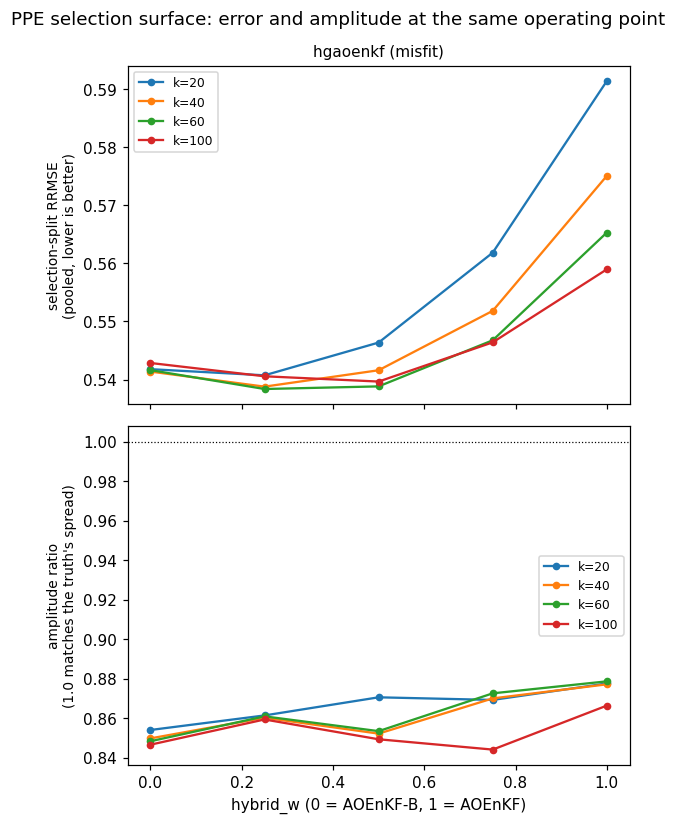

In [8]:
def ppe_surface(rule, metric="rrmse"):
    """Selection-split ``metric`` at each (k, hybrid_w), read at the RRMSE-optimal b_scale.

    Amplitude is read at the operating point RRMSE picks rather than optimised on its own:
    the pair is what says whether a low error was bought by flattening the field.
    """
    m = pd.read_csv(HG[rule] / "metrics.csv")
    label = ex.method_label(ex.hgaoenkf_estimator(rule))
    sel = m[(m.lane == "ppe") & (m.split == "selection") & (m.method == label)
            & (m.channel == "pooled") & (m.do_event == "all")]
    rrmse = sel[sel.metric == "rrmse"]
    best = rrmse.loc[rrmse.groupby(["analog_k", "hybrid_w"])["value"].idxmin(),
                     ["analog_k", "hybrid_w", "b_scale"]]
    at_best = sel[sel.metric == metric].merge(best, on=["analog_k", "hybrid_w", "b_scale"])
    return at_best.set_index(["analog_k", "hybrid_w"])["value"].unstack()


have = [rule for rule in RULES if (HG[rule] / "metrics.csv").exists()]
if len(have) < len(RULES):
    print(f"no PPE rows for {set(RULES) - set(have)}; run those rules to compare them")

# Error and amplitude at the same operating point, so a flat reconstruction cannot hide
# behind an RRMSE that barely moves with it.
PANELS = (("rrmse", "selection-split RRMSE\n(pooled, lower is better)"),
          ("amplitude", "amplitude ratio\n(1.0 matches the truth's spread)"))

fig, axes = plt.subplots(len(PANELS), len(have), squeeze=False, sharex=True, sharey="row",
                         figsize=(5.6 * len(have), 3.8 * len(PANELS)))
for row, (metric, ylabel) in enumerate(PANELS):
    for col, rule in enumerate(have):
        ax = axes[row, col]
        surface = ppe_surface(rule, metric)
        if metric == "rrmse":
            print(f"{rule}: selection-split RRMSE at each (k, hybrid_w), "
                  "minimised over b_scale:")
            display(surface.round(4))
        for k, values in surface.iterrows():
            ax.plot(values.index, values.values, marker="o", ms=4, label=f"k={int(k)}")
        if metric == "amplitude":
            ax.axhline(1.0, color="k", lw=0.8, ls=":")
            ax.set_xlabel("hybrid_w (0 = AOEnKF-B, 1 = AOEnKF)")
        else:
            ax.set_title(RULE_LABEL[rule], fontsize=10)
        if col == 0:
            ax.set_ylabel(ylabel, fontsize=9)
        ax.legend(fontsize=8)
fig.suptitle("PPE selection surface: error and amplitude at the same operating point")
fig.tight_layout()
fig.savefig(FIG / "ppe_selection_surface.png", bbox_inches="tight")
plt.show()

## Trajectory lane

Every state of the younger half reconstructed in sequence with the real network at each
age, so the analyses form a time series and skill can be resolved by timescale. Each rule
inherits the PPE taper and its own PPE-selected operating point, and sweeps `b_scale` alone.

All three treatments of observation staleness run here, plus the ceiling that reads the
observations at the analysis age. That ladder is a property of the observation layer rather
than of any estimator, so it is scored at one operating point per rule rather than letting
the treatment vary alongside the analog parameters. The order matches the 3DVar run, which
means the `recon_realistic` field of every directory holds the **uncorrected** run and the
deflated one rides alongside under its own key; notebook 09 reads the deflated field by
name.

The lane also records which prior states each analysis drew on, for the first treatment in
the ladder. Analog selection is discrete, so the chosen set turns over between neighbouring
ages and both the prior mean and the covariance jump with it. That is a high-frequency
source a fixed-covariance analysis does not have, and it is the thing to look at first if
the fastest bands come out worse than 3DVar's.

In [9]:
# The correlation rule rides along at the reading the demonstration preferred, so the
# timescale picture covers the published rule as well as the two candidates.
TRAJ_RULES = RULES + (CORR_BEST,)

traj_cfg = {}
for rule in TRAJ_RULES:
    run_this = RUN_TRAJECTORY and rule in RUN_RULES
    if run_this and rule not in K_SEL:
        raise RuntimeError(f"the trajectory lane runs at {rule}'s PPE-selected "
                           "(k, hybrid_w); run its PPE grid first")
    if run_this:
        shutil.rmtree(HG_TRAJ[rule], ignore_errors=True)
        print(f"[{rule}] trajectory at k={K_SEL[rule]}, hybrid_w={W_SEL[rule]}, "
              f"analog lengthscale {loc_label(LOC_SEL.get(rule))}")
        ex.run_trajectory(
            cube, ages, lats, lons, valid, long_ppe, str(HG_TRAJ[rule]),
            make_method=make_hgaoenkf(cube, ages, lats, lons, k=K_SEL[rule],
                                      hybrid_w=W_SEL[rule], selection=rule,
                                      analog_localization_km=LOC_SEL.get(rule)),
            estimator=ex.hgaoenkf_estimator(rule),
            method_cols=ex.analog_cols(K_SEL[rule], W_SEL[rule]),
            temporal_modes=ex.TEMPORAL_MODES, progress_every=50, **TAPER_PPE)
    else:
        print(f"[{rule}] trajectory lane off; reading the last run")

    cfg = last_run(HG_TRAJ[rule] / "trajectory_config.json", run_this, "trajectory")
    if cfg is not None:
        traj_cfg[rule] = cfg
        print(f"  scored {cfg['n_covered_ages']} ages, skipped {cfg['n_skipped_ages']}")
        print(f"  selection {cfg['selection_ages']} yr BP, test {cfg['test_ages']} yr BP")
        print("  b_scale* per method:", cfg["selected_b_scale_by_method"])

[misfit] trajectory at k=60, hybrid_w=0.25, analog lengthscale static
  trajectory age 87/402 (22%, elapsed 21s, eta 77s)
  trajectory age 137/402 (34%, elapsed 48s, eta 93s)
  trajectory age 187/402 (47%, elapsed 66s, eta 76s)
  trajectory age 237/402 (59%, elapsed 82s, eta 57s)
  trajectory age 287/402 (71%, elapsed 100s, eta 40s)
  trajectory age 337/402 (84%, elapsed 120s, eta 23s)
  trajectory age 387/402 (96%, elapsed 136s, eta 5s)
  scored 365 ages, skipped 37
  selection [30025, 34550] yr BP, test [34575, 39125] yr BP
  b_scale* per method: {'hgaoenkf': 0.3, 'hgaoenkf_temporal_add': 0.3, 'hgaoenkf_temporal_deflate': 0.3}
[correlation_perchan] trajectory at k=40, hybrid_w=0.5, analog lengthscale static
  trajectory age 87/402 (22%, elapsed 15s, eta 55s)
  trajectory age 137/402 (34%, elapsed 35s, eta 68s)
  trajectory age 187/402 (47%, elapsed 50s, eta 58s)
  trajectory age 237/402 (59%, elapsed 64s, eta 44s)
  trajectory age 287/402 (71%, elapsed 83s, eta 33s)
  trajectory age 

misfit: analog-set overlap between neighbouring analyses (25 yr apart):
  mean 0.717, median 0.733, 10th pct 0.500
  fraction of adjacent pairs sharing under half their members: 0.093
  overlap beyond 1000 yr: 0.144 (chance = 0.149)
correlation_perchan: analog-set overlap between neighbouring analyses (25 yr apart):
  mean 0.327, median 0.300, 10th pct 0.025
  fraction of adjacent pairs sharing under half their members: 0.731
  overlap beyond 1000 yr: 0.086 (chance = 0.100)


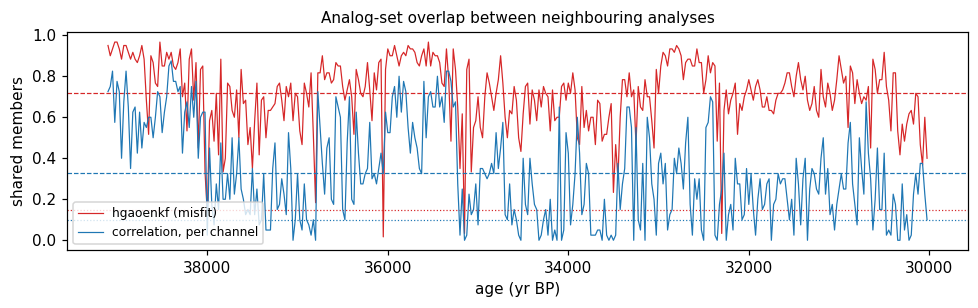


The lane records the selection made by the first treatment in the ladder, which is the uncorrected one; deflating y and R moves which states are chosen, so read this as the structure of analog selection rather than as the deflated run's own set. Overlap at chance for distant ages means selection carries real information about the epoch. Turnover between neighbours is what can inject variance into the fastest bands, so read this next to the band table in notebook 09.


In [10]:
if not traj_cfg:
    raise RuntimeError("no trajectory run to read")

fig, ax = plt.subplots(figsize=(9, 2.9))
for rule, colour in zip(traj_cfg, ("C3", "C0", "C2", "C4")):
    zt = np.load(HG_TRAJ[rule] / "trajectory_analysis.npz")
    idx = zt["analog_index"]
    step_yr = float(zt["step_yr"])
    sets = [set(row.tolist()) for row in idx]
    k = idx.shape[1]
    chance = k / traj_cfg[rule]["prior_meta"]["n_prior_ages"]

    adjacent = np.array([len(sets[i] & sets[i + 1]) / k for i in range(len(sets) - 1)])
    far = np.array([len(sets[i] & sets[j]) / k
                    for i in range(0, len(sets), 17) for j in range(0, len(sets), 19)
                    if abs(i - j) * step_yr > 1000])

    print(f"{rule}: analog-set overlap between neighbouring analyses "
          f"({step_yr:.0f} yr apart):")
    print(f"  mean {adjacent.mean():.3f}, median {np.median(adjacent):.3f}, "
          f"10th pct {np.percentile(adjacent, 10):.3f}")
    print(f"  fraction of adjacent pairs sharing under half their members: "
          f"{np.mean(adjacent < 0.5):.3f}")
    print(f"  overlap beyond 1000 yr: {far.mean():.3f} (chance = {chance:.3f})")

    ax.plot(zt["ages"][:-1], adjacent, lw=0.8, color=colour, label=RULE_LABEL[rule])
    ax.axhline(adjacent.mean(), color=colour, lw=0.8, ls="--")
    # k can differ between rules, so each carries its own chance level.
    ax.axhline(chance, color=colour, lw=0.8, ls=":")
ax.set_xlabel("age (yr BP)"); ax.set_ylabel("shared members")
ax.set_title("Analog-set overlap between neighbouring analyses", fontsize=10)
ax.invert_xaxis(); ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(FIG / "analog_set_stability.png", bbox_inches="tight")
plt.show()

print("\nThe lane records the selection made by the first treatment in the ladder, which "
      "is the uncorrected one; deflating y and R moves which states are chosen, so read "
      "this as the structure of analog selection rather than as the deflated run's own "
      "set. Overlap at chance for distant ages means selection carries real information "
      "about the epoch. Turnover between neighbours is what can inject variance into the "
      "fastest bands, so read this next to the band table in notebook 09.")

## Withholding lane

Nested cross-validation over proxy sites: the only lane whose truth is real pollen rather
than a model state. Each rule picks its own `(k, hybrid_w)` here rather than inheriting the
PPE choice, because this lane's residual is dominated by proxy-versus-model mismatch rather
than by covariance error, and it may well want a different amount of analog information. A
divergence would itself be a result, in the same shape as the taper divergence notebook 07
surfaced.

This lane's prior spans every age, including the one being reconstructed, so an exclusion
band drops candidates within `EXCLUDE_YR` of the target from the analog pool. Without it
the analog step can select the simulation's own state at the target age, which both
degenerates the method into a per-age background and inherits whatever alignment the proxy
chronology was given against that simulation. The ablation below sweeps the width, which is
the only justification for a number that appears in no paper.

The grid runs at one treatment of staleness, so the analog parameters are selected under a
single observation model; the winner is then re-scored under all three, which is how the
3DVar taper grid handles the same ladder.

In [11]:
EXCLUDE_YR = ex.EXCLUDE_YR

K_WH, W_WH = {}, {}
for rule in RULES:
    run_this = RUN_WITHHOLDING and rule in RUN_RULES
    if run_this:
        clear_lane(HG[rule], "withholding_random")
        print(f"[{rule}] withholding analog grid, exclusion band {EXCLUDE_YR:.0f} yr")
        ex.run_hgaoenkf_withholding_grid(
            cube, ages, lats, lons, valid, long_wh, str(HG[rule]),
            k_grid=K_GRID, hybrid_w_grid=W_GRID, exclude_yr=EXCLUDE_YR, selection=rule,
            report_temporal_modes=ex.TEMPORAL_MODES,
            k_folds=5, progress_every=1, **TAPER_WH)
    else:
        print(f"[{rule}] withholding grid off; reading the last run")

    cfg = last_run(HG[rule] / "withholding_random_config.json", run_this, "withholding")
    if cfg is not None:
        K_WH[rule], W_WH[rule] = cfg["selected"]["analog_k"], cfg["selected"]["hybrid_w"]
        print(f"selected on withholding ({rule}): k={K_WH[rule]}, hybrid_w={W_WH[rule]}, "
              f"b_scale={cfg['selected']['b_scale']}")
        print(f"selected on PPE         ({rule}): k={K_SEL.get(rule)}, "
              f"hybrid_w={W_SEL.get(rule)}")
        if (K_WH[rule], W_WH[rule]) != (K_SEL.get(rule), W_SEL.get(rule)):
            print("  the two lanes disagree. They measure different things: the PPE lane "
                  "scores a model state drawn from the same distribution as the prior, the "
                  "withholding lane scores real pollen and is the only one whose truth is "
                  "independent of the model. Report the gap rather than averaging it.")

[misfit] withholding analog grid, exclusion band 1000 yr
  analog-grid config (withholding_random) 1/20 (5%, elapsed 457s, eta 8684s)
  analog-grid config (withholding_random) 2/20 (10%, elapsed 891s, eta 8019s)
  analog-grid config (withholding_random) 3/20 (15%, elapsed 1318s, eta 7469s)
  analog-grid config (withholding_random) 4/20 (20%, elapsed 1699s, eta 6795s)
  analog-grid config (withholding_random) 5/20 (25%, elapsed 2066s, eta 6199s)
  analog-grid config (withholding_random) 6/20 (30%, elapsed 2567s, eta 5991s)
  analog-grid config (withholding_random) 7/20 (35%, elapsed 3139s, eta 5829s)
  analog-grid config (withholding_random) 8/20 (40%, elapsed 3544s, eta 5317s)
  analog-grid config (withholding_random) 9/20 (45%, elapsed 3861s, eta 4719s)
  analog-grid config (withholding_random) 10/20 (50%, elapsed 4179s, eta 4179s)
  analog-grid config (withholding_random) 11/20 (55%, elapsed 4649s, eta 3804s)
  analog-grid config (withholding_random) 12/20 (60%, elapsed 5129s, eta 34

### The analog lengthscale on real proxies

The same sweep as on the PPE lane, repeated here because this lane answers a different
question and its static covariance is regularized differently: notebook 07 selected no
Gaspari-Cohn taper for it at all. A static covariance with no localization and an analog
covariance with a finite one is exactly the arrangement of Sun et al. (2024) Table 2, so
this is the closest this project gets to reproducing their configuration.

**The operating point is not re-selected afterwards.** `(k, hybrid_w)` was chosen under the
inherited lengthscale, and re-gridding here costs about eighty minutes per rule. The taper
itself is already inherited rather than re-gridded on this lane for the same reason, so this
is consistent with existing practice rather than a new compromise, but it is a caveat and
belongs in the write-up.

In [12]:
LOC_SEL_WH = {rule: None for rule in RULES}

if RUN_LOC_SWEEP_WH:
    missing = [r for r in RULES if r not in K_WH]
    if missing:
        raise RuntimeError("the withholding lengthscale sweep runs at each rule's "
                           f"withholding-selected (k, hybrid_w); run the grid for {missing}")
    for rule in RULES:
        shutil.rmtree(HG_LOC_WH[rule], ignore_errors=True)
        variants = tuple(
            (ex.analog_localization_estimator(rule, km),
             dict(selection=rule, exclude_yr=EXCLUDE_YR, analog_localization_km=km))
            for km in LOC_GRID_WH)
        print(f"[{rule}] withholding lengthscale sweep at k={K_WH[rule]}, "
              f"hybrid_w={W_WH[rule]}")
        ex.run_hgaoenkf_withholding_variants(
            cube, ages, lats, lons, valid, long_wh, str(HG_LOC_WH[rule]),
            k=K_WH[rule], hybrid_w=W_WH[rule], variants=variants,
            k_folds=5, progress_every=1, **TAPER_WH)
else:
    print("[hgaoenkf] withholding lengthscale sweep off; reading the last run")

rows = []
for rule in RULES:
    path = HG_LOC_WH[rule] / "metrics.csv"
    if not path.exists():
        continue
    M_LW = pd.read_csv(path)
    for km in LOC_GRID_WH:
        label = ex.method_label(ex.analog_localization_estimator(rule, km), ex.TEMPORAL_DEFLATE)
        sel = M_LW[(M_LW.split == "selection") & (M_LW.method == label)
                   & (M_LW.channel == "pooled") & (M_LW.do_event == "all")
                   & (M_LW.metric == "rrmse")]
        if len(sel):
            rows.append({"rule": RULE_LABEL[rule], "km": km, "lengthscale": loc_label(km),
                         "selection rrmse": float(sel["value"].min())})

if not rows:
    print("[hgaoenkf] no withholding lengthscale sweep on disk; staying at the static value")
else:
    loc_wh_tab = pd.DataFrame(rows)
    print("Withholding selection split against the analog lengthscale:")
    display(loc_wh_tab.pivot(index="lengthscale", columns="rule",
                             values="selection rrmse").round(4))
    for rule in RULES:
        sub = loc_wh_tab[loc_wh_tab.rule == RULE_LABEL[rule]]
        if len(sub):
            LOC_SEL_WH[rule] = pick_lengthscale(sub, LOC_GRID_WH)
    print(f"selected analog lengthscale, withholding "
          f"(adoption margin {100 * SEL_MARGIN:.0f}%):",
          {RULE_LABEL[r]: loc_label(LOC_SEL_WH[r]) for r in RULES})

[misfit] withholding lengthscale sweep at k=100, hybrid_w=0.75
  analog variant 1/4 (25%, elapsed 894s, eta 2683s)
  analog variant 2/4 (50%, elapsed 1828s, eta 1828s)
  analog variant 3/4 (75%, elapsed 2793s, eta 931s)
  analog variant 4/4 (100%, elapsed 3899s, eta 0s)
Withholding selection split against the analog lengthscale:


rule,hgaoenkf (misfit)
lengthscale,
10000,0.9598
15000,0.9594
5000,0.9608
static,0.9589


selected analog lengthscale, withholding (adoption margin 1%): {'hgaoenkf (misfit)': 'static'}


## Ablation: how wide the exclusion band has to be

The withholding lane's prior spans every age including the one being reconstructed, so
without a band the analog step can select the simulation's own state at the target.
`EXCLUDE_YR` appears in no paper, so sweeping it is the only thing that justifies the value
the baseline carries. Flat in the width means nothing was being exploited and the band costs
nothing; a drop from zero that then flattens is the circularity, quantified, and it belongs
in the disclosure of how far the chronology depends on the model.

The sweep runs at the baseline's withholding-selected operating point and its selected
analog lengthscale, so what separates the rows is the band and nothing else.

In [13]:
if RUN_ABLATIONS and ANALOG_MISFIT not in K_WH:
    raise RuntimeError("the ablation runs at the baseline's withholding-selected "
                       "(k, hybrid_w); run the withholding grid first")

if RUN_ABLATIONS:
    k_abl, w_abl = K_WH[ANALOG_MISFIT], W_WH[ANALOG_MISFIT]
    shutil.rmtree(HG_ABL, ignore_errors=True)
    variants = tuple(
        (ex.analog_variant_estimator(ANALOG_MISFIT, w),
         dict(selection=ANALOG_MISFIT, exclude_yr=w,
              analog_localization_km=LOC_SEL_WH.get(ANALOG_MISFIT)))
        for w in ex.EXCLUDE_YR_GRID)
    print(f"[hgaoenkf] exclusion-width ablation at k={k_abl}, hybrid_w={w_abl}, "
          f"analog lengthscale {loc_label(LOC_SEL_WH.get(ANALOG_MISFIT))}")
    ex.run_hgaoenkf_withholding_variants(
        cube, ages, lats, lons, valid, long_wh, str(HG_ABL),
        k=k_abl, hybrid_w=w_abl, variants=variants,
        k_folds=5, progress_every=1, **TAPER_WH)
else:
    print("[hgaoenkf] ablation off; reading the last run")

if not (HG_ABL / "metrics.csv").exists():
    print("[hgaoenkf] no ablation runs on disk")
else:
    M_ABL = pd.read_csv(HG_ABL / "metrics.csv")
    abl = M_ABL[(M_ABL.split == "test") & (M_ABL.fold == -1) & (M_ABL.channel == "pooled")
                & (M_ABL.metric.isin(["ce", "corr", "amplitude"]))]
    best_b = (M_ABL[(M_ABL.split == "selection") & (M_ABL.channel == "pooled")
                    & (M_ABL.metric == "rrmse")]
              .loc[lambda d: d.groupby("method")["value"].idxmin()]
              .set_index("method")["b_scale"])
    abl = abl[abl.apply(lambda r: np.isclose(r.b_scale, best_b.get(r.method, np.nan)),
                        axis=1)]
    tab = abl.pivot_table(index="method", columns="metric", values="value")
    tab["b_scale*"] = [best_b.get(m, np.nan) for m in tab.index]
    print("Withholding test split, each width at its own selected b_scale:")
    display(tab.round(4))

[hgaoenkf] exclusion-width ablation at k=100, hybrid_w=0.75, analog lengthscale static
  analog variant 1/3 (33%, elapsed 1026s, eta 2053s)
  analog variant 2/3 (67%, elapsed 1965s, eta 982s)
  analog variant 3/3 (100%, elapsed 2756s, eta 0s)
Withholding test split, each width at its own selected b_scale:


metric,amplitude,ce,corr,b_scale*
method,,,,
hgaoenkf_misfit_excl0_temporal_deflate,0.3253,0.0890,0.2997,5.0
hgaoenkf_misfit_excl1000_temporal_deflate,0.3269,0.0890,0.2997,5.0
hgaoenkf_misfit_excl2000_temporal_deflate,0.3279,0.0892,0.3001,5.0


## Reading

- The correlation demonstration is what licenses the baseline. It should show misfit ahead
  of both readings of Eq. 3; if it does not, the cell stops the notebook rather than letting
  the baseline stand on an assumption the data contradicts.
- The selection surface is the next thing to check. It spans the published family:
  `hybrid_w = 0` is AOEnKF-B and `hybrid_w = 1` is AOEnKF, with 3DVar a reference line from
  its own run rather than an endpoint of the blend. An interior optimum reproduces Sun et
  al.'s result; an optimum at `hybrid_w = 0` says the flow-dependent covariance earns nothing
  on this prior and the analog mean carries the whole margin, which is a finding rather than
  a failure. Read the amplitude panel beside it before believing a low RRMSE.
- `hybrid_w = 1` is the pure analog prior. If it beats the blend, the static covariance is
  contributing nothing and that is worth saying.
- The analog lengthscale answers Sun et al.'s ensemble-size question directly. A sweep that
  prefers something tighter than the static value reproduces their Table 2 schedule on this
  prior; a flat one says the long-range correlations localization would suppress are
  carrying signal here rather than sampling noise, which is a finding about this prior's two
  dominant modes rather than about the method.
- HGAOEnKF selects a higher `b_scale` than 3DVar. Analogs are chosen for closeness to the
  observations, so their spread is smaller than the climatology's and the covariance needs
  more inflating. The selected `b_scale` rises with `hybrid_w` for the same reason, which
  is the mechanism read along the other axis.
- Expect the ensemble to be **worse** calibrated than 3DVar's analytic posterior variance.
  A k-member sample covariance cannot support full-rank spread, and the deviation update
  reduces analog deviations by a partly static gain, so the mean and the spread come from
  different mixtures. That is a property of the published scheme, not a bug here; report it.
- Check where `k` lands. A rule selecting `k` at an edge of `K_GRID` on a lane has not had
  its optimum bracketed there, and the reported point is a grid edge rather than a minimum.
- The exclusion-width ablation is the disclosure that the analog step is not reading the
  chronology. It is the only justification for a band width that appears in no paper.
- The timescale curves, the staleness ladder and the paired intervals are all in notebook
  09, which reads every lane through the shared metrics CSV. Notebook 11 carries the
  extension and is compared against this baseline there.